In [1]:
pip install tensorflow gensim transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 26.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec

In [3]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples: {len(x_train_raw)}")
print(f"Test samples:     {len(x_test_raw)}")
print(f"Class distribution (train) — Positive: {y_train.sum()}, Negative: {(1-y_train).sum()}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Test samples:     25000
Class distribution (train) — Positive: 12500, Negative: 12500


### Decoding

In [4]:
word_index = imdb.get_word_index()
# Offset by 3 (reserved indices: 0=padding, 1=start, 2=unknown, 3=unused)
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word[0] = '<PAD>'
index_to_word[1] = '<START>'
index_to_word[2] = '<UNK>'

def decode_review(encoded):
    return ' '.join([index_to_word.get(i, '<UNK>') for i in encoded])

x_train_text = [decode_review(r) for r in x_train_raw]
x_test_text  = [decode_review(r) for r in x_test_raw]

print("Sample raw decoded review:")
print(x_train_text[0][:300])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Sample raw decoded review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the


## NLP preprocessing

In [5]:
print("=" * 60)
print("5 RAW REVIEWS")
print("=" * 60)
for i in range(5):
    label = "Positive" if y_train[i] == 1 else "Negative"
    print(f"\n[Review {i+1}] Label: {label}")
    print(x_train_text[i][:200])

5 RAW REVIEWS

[Review 1] Label: Positive
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and 

[Review 2] Label: Negative
<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the

[Review 3] Label: Negative
<START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first half an hour with our jaws 

[Review 4] Label: Positive
<START> the <UNK> <UNK> at storytelling the traditional sort many years after the event i can still see in my <UNK> eye an elderly lady my friend's mother retelling the battle of <UNK> she makes the c

[Review 5] Label: Negative
<START> worst mistake of my life br br i p

In [6]:
# text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)          # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)       # remove non-alpha characters
    text = re.sub(r'\s+', ' ', text).strip()   # normalize whitespace
    return text

x_train_clean = [clean_text(r) for r in x_train_text]
x_test_clean  = [clean_text(r) for r in x_test_text]

print("=" * 60)
print("5 REVIEWS AFTER CLEANING")
print("=" * 60)
for i in range(5):
    label = "Positive" if y_train[i] == 1 else "Negative"
    print(f"\n[Review {i+1}] Label: {label}")
    print(x_train_clean[i][:200])

5 REVIEWS AFTER CLEANING

[Review 1] Label: Positive
this film was just brilliant casting location scenery story direction everyones really suited the part they played and you could just imagine being there robert is an amazing actor and now the same be

[Review 2] Label: Negative
big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and ive seen hundreds but this had got to be on of the worst ev

[Review 3] Label: Negative
this has to be one of the worst films of the s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first half an hour with our jaws touching the

[Review 4] Label: Positive
the at storytelling the traditional sort many years after the event i can still see in my eye an elderly lady my friends mother retelling the battle of she makes the characters come alive her passion 

[Review 5] Label: Negative
worst mistake of my life br br 

In [7]:
# tokenization
x_train_tokens = [text.split() for text in x_train_clean]
x_test_tokens  = [text.split() for text in x_test_clean]

print("Tokenized representation of 2 reviews:")
for i in range(2):
    print(f"\nReview {i+1} tokens (first 20): {x_train_tokens[i][:20]}")

lengths = [len(t) for t in x_train_tokens]
print(f"\nAverage review length: {np.mean(lengths):.1f} tokens")
print(f"Maximum review length: {np.max(lengths)} tokens")

Tokenized representation of 2 reviews:

Review 1 tokens (first 20): ['this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyones', 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could']

Review 2 tokens (first 20): ['big', 'hair', 'big', 'boobs', 'bad', 'music', 'and', 'a', 'giant', 'safety', 'pin', 'these', 'are', 'the', 'words', 'to', 'best', 'describe', 'this', 'terrible']

Average review length: 222.7 tokens
Maximum review length: 2181 tokens


In [8]:
# padding for neural networks
x_train_pad = pad_sequences(x_train_raw, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad  = pad_sequences(x_test_raw,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Padded train shape: {x_train_pad.shape}")
print(f"Padded test shape:  {x_test_pad.shape}")

Padded train shape: (25000, 200)
Padded test shape:  (25000, 200)


## TF-IDF Baseline                                                     

=== TF-IDF + Logistic Regression ===
Test Accuracy:  0.8951
Precision:      0.8912
Recall:         0.9000
F1-Score:       0.8956


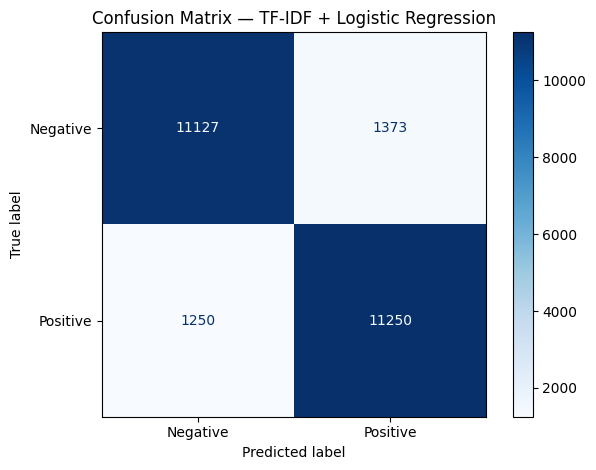

In [9]:
# --- What TF-IDF represents ---
"""
TF-IDF (Term Frequency–Inverse Document Frequency) converts text into
numerical vectors. TF measures how often a word appears in a single
document. IDF down-weights words that appear in many documents (e.g.,
"the", "is"), making them less informative. The product TF × IDF gives
high scores to words that are frequent in a specific document but rare
overall — capturing the words most characteristic of that document.
Because most words are absent from any given document, TF-IDF vectors
are mostly zeros, making them sparse.
"""

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
x_train_tfidf = tfidf.fit_transform(x_train_clean)   # fit ONLY on train
x_test_tfidf  = tfidf.transform(x_test_clean)

lr = LogisticRegression(max_iter=500, C=1.0)
lr.fit(x_train_tfidf, y_train)
y_pred_lr = lr.predict(x_test_tfidf)

acc_lr  = accuracy_score(y_train, lr.predict(x_train_tfidf))   # train acc
acc_lr_test = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print("=== TF-IDF + Logistic Regression ===")
print(f"Test Accuracy:  {acc_lr_test:.4f}")
print(f"Precision:      {prec_lr:.4f}")
print(f"Recall:         {rec_lr:.4f}")
print(f"F1-Score:       {f1_lr:.4f}")

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — TF-IDF + Logistic Regression')
plt.tight_layout()
plt.show()

In [10]:
# Challenge: effect of ngram_range and max_features
configs = [
    {'max_features': 5000,  'ngram_range': (1, 1)},
    {'max_features': 20000, 'ngram_range': (1, 1)},
    {'max_features': 20000, 'ngram_range': (1, 2)},
]

print(f"{'max_features':<14} {'ngram_range':<14} {'F1':>6}")
print("-" * 38)
for cfg in configs:
    vec = TfidfVectorizer(**cfg)
    Xtr = vec.fit_transform(x_train_clean)
    Xte = vec.transform(x_test_clean)
    m = LogisticRegression(max_iter=300).fit(Xtr, y_train)
    f1 = f1_score(y_test, m.predict(Xte))
    print(f"{cfg['max_features']:<14} {str(cfg['ngram_range']):<14} {f1:.4f}")


max_features   ngram_range        F1
--------------------------------------
5000           (1, 1)         0.8843
20000          (1, 1)         0.8841
20000          (1, 2)         0.8956


## Word2Vec

In [11]:
w2v_model = Word2Vec(
    sentences=x_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print("Word2Vec training complete.")
print(f"Vocabulary size: {len(w2v_model.wv)}")

# Vector of one word
print("\nVector for 'excellent' (first 10 dims):")
print(w2v_model.wv['excellent'][:10])

Word2Vec training complete.
Vocabulary size: 9745

Vector for 'excellent' (first 10 dims):
[-0.36102802 -0.25688154  0.21136351 -1.1740829  -3.4503713  -0.23266587
 -2.5460558  -0.9196166  -0.91824394  1.1929541 ]


In [12]:
# most similar
"""
Why Word2Vec differs from TF-IDF:
TF-IDF represents each document as a sparse vector of word counts weighted
by rarity — words have no relationship to each other. Word2Vec instead
learns dense vectors (embeddings) for each word by training a neural network
to predict surrounding words. Words used in similar contexts end up with
similar vectors, so "good" and "great" are close in embedding space. This
captures semantic meaning that TF-IDF completely ignores.
"""

for word in ['good', 'terrible', 'actor']:
    print(f"\nMost similar to '{word}':")
    for w, score in w2v_model.wv.most_similar(word, topn=5):
        print(f"  {w:<20} {score:.4f}")


Most similar to 'good':
  bad                  0.7798
  great                0.7497
  decent               0.7352
  ok                   0.6534
  nice                 0.6527

Most similar to 'terrible':
  horrible             0.9205
  awful                0.8291
  atrocious            0.7692
  bad                  0.7681
  horrendous           0.7583

Most similar to 'actor':
  actress              0.7463
  performer            0.6539
  comedian             0.6508
  role                 0.6312
  performance          0.6130


## RNN Model

In [13]:
# build and train model
def build_rnn(vocab_size=VOCAB_SIZE, embed_dim=64, units=64):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=MAX_LEN),
        SimpleRNN(units, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

rnn_model = build_rnn()
rnn_model.summary()

es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
rnn_history = rnn_model.fit(
    x_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.5091 - loss: 0.6946 - val_accuracy: 0.5008 - val_loss: 0.6938
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.5189 - loss: 0.6919 - val_accuracy: 0.5050 - val_loss: 0.6935
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.5780 - loss: 0.6699 - val_accuracy: 0.4918 - val_loss: 0.7113
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.6696 - loss: 0.5353 - val_accuracy: 0.5138 - val_loss: 0.7766


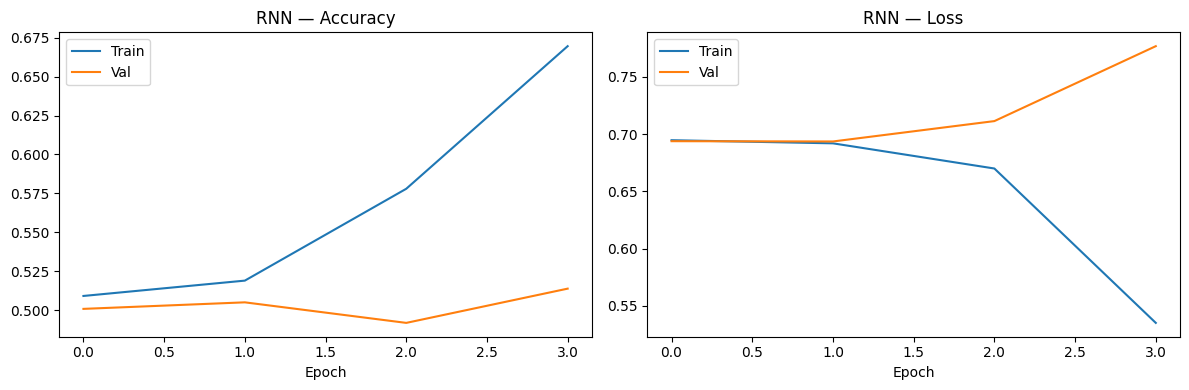

RNN Test Accuracy: 0.4990 | Precision: 0.4984 | Recall: 0.3073 | F1: 0.3802


In [14]:
# evaluate RNN
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(rnn_history, 'RNN')

rnn_loss, rnn_acc = rnn_model.evaluate(x_test_pad, y_test, verbose=0)
y_pred_rnn = (rnn_model.predict(x_test_pad, verbose=0) > 0.5).astype(int).flatten()
prec_rnn = precision_score(y_test, y_pred_rnn)
rec_rnn  = recall_score(y_test, y_pred_rnn)
f1_rnn   = f1_score(y_test, y_pred_rnn)

print(f"RNN Test Accuracy: {rnn_acc:.4f} | Precision: {prec_rnn:.4f} | Recall: {rec_rnn:.4f} | F1: {f1_rnn:.4f}")


## LSTM Model

In [15]:
def build_lstm(vocab_size=VOCAB_SIZE, embed_dim=64, units=64):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=MAX_LEN),
        LSTM(units, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm()
lstm_model.summary()

lstm_history = lstm_model.fit(
    x_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 430ms/step - accuracy: 0.5134 - loss: 0.6938 - val_accuracy: 0.5146 - val_loss: 0.6940
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 463ms/step - accuracy: 0.5630 - loss: 0.6899 - val_accuracy: 0.5946 - val_loss: 0.6458
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 396ms/step - accuracy: 0.6287 - loss: 0.6081 - val_accuracy: 0.6476 - val_loss: 0.5932
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 411ms/step - accuracy: 0.7333 - loss: 0.5471 - val_accuracy: 0.5426 - val_loss: 0.6858
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - accuracy: 0.5810 - loss: 0.6638 - val_accuracy: 0.5592 - val_loss: 0.6592


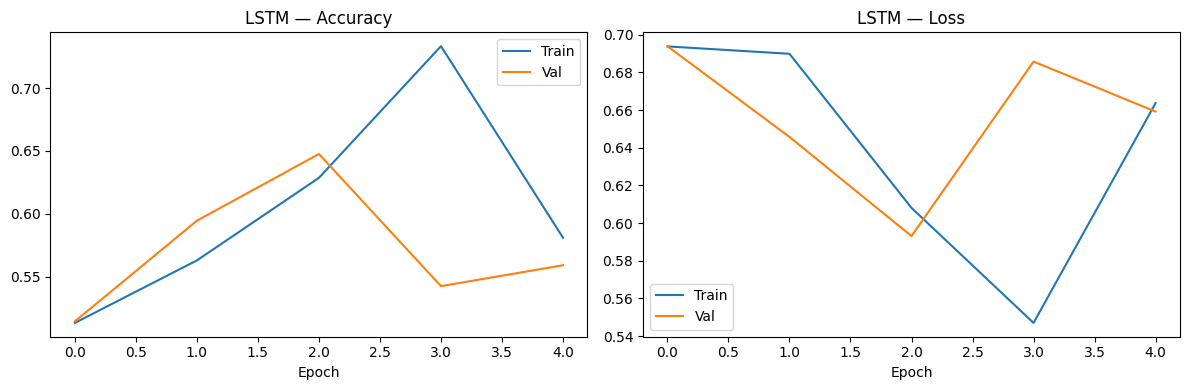

LSTM Test Accuracy: 0.6317 | Precision: 0.5875 | Recall: 0.8840 | F1: 0.7059


In [16]:
# evaluate
plot_history(lstm_history, 'LSTM')

lstm_loss, lstm_acc = lstm_model.evaluate(x_test_pad, y_test, verbose=0)
y_pred_lstm = (lstm_model.predict(x_test_pad, verbose=0) > 0.5).astype(int).flatten()
prec_lstm = precision_score(y_test, y_pred_lstm)
rec_lstm  = recall_score(y_test, y_pred_lstm)
f1_lstm   = f1_score(y_test, y_pred_lstm)

print(f"LSTM Test Accuracy: {lstm_acc:.4f} | Precision: {prec_lstm:.4f} | Recall: {rec_lstm:.4f} | F1: {f1_lstm:.4f}")


## Transformer

In [17]:
# Run pretrained Transformer on 10 reviews
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Pick 10 test reviews
sample_texts  = x_test_clean[:10]
sample_labels = y_test[:10]

print(f"{'True Label':<12} {'Model Prediction':<14} {'Score':<8} {'Match?'}")
print("-" * 55)
for text, true_label in zip(sample_texts, sample_labels):
    result = classifier(text[:512])[0]
    pred_label = 1 if result['label'] == 'POSITIVE' else 0
    true_str = "Positive" if true_label == 1 else "Negative"
    pred_str = result['label'].capitalize()
    match = "matching" if pred_label == true_label else "not matching"
    print(f"{true_str:<12} {pred_str:<14} {result['score']:.4f}   {match}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

True Label   Model Prediction Score    Match?
-------------------------------------------------------
Negative     Negative       0.9995   matching
Positive     Positive       0.9759   matching
Positive     Positive       0.9989   matching
Negative     Negative       0.9769   matching
Positive     Positive       0.9996   matching
Positive     Negative       0.9797   not matching
Positive     Negative       0.9714   not matching
Negative     Negative       0.9961   matching
Negative     Negative       0.9756   matching
Positive     Negative       0.9954   not matching


## Final Comparison Table

In [18]:
results = {
    'Model':     ['TF-IDF + LR', 'RNN', 'LSTM', 'Transformer (pretrained)'],
    'Accuracy':  [round(acc_lr_test, 4), round(rnn_acc, 4), round(lstm_acc, 4), 'See output above'],
    'Precision': [round(prec_lr, 4),     round(prec_rnn, 4), round(prec_lstm, 4), '—'],
    'Recall':    [round(rec_lr, 4),      round(rec_rnn, 4),  round(rec_lstm, 4),  '—'],
    'F1-Score':  [round(f1_lr, 4),       round(f1_rnn, 4),   round(f1_lstm, 4),   '—'],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

                   Model         Accuracy Precision  Recall F1-Score
             TF-IDF + LR           0.8951    0.8912     0.9   0.8956
                     RNN            0.499    0.4984  0.3073   0.3802
                    LSTM           0.6317    0.5875   0.884   0.7059
Transformer (pretrained) See output above         —       —        —


**Questions :**
1. What is NLP and why do computers need text preprocessing?                     
   NLP (Natural Language Processing) is the field that enables computers to understand, interpret,
   and generate human language. Preprocessing is needed because raw text is noisy and inconsistent —
   it contains symbols, HTML, mixed casing, and variable lengths that ML models cannot handle directly.

2. What is the difference between a token, a sequence, and an embedding?         
   A token is a single unit of text (usually a word). A sequence is an ordered list of tokens
   representing a document. An embedding is a dense numerical vector that encodes the meaning of
   a token or sequence in a continuous vector space.

3. Why can raw text not be directly passed to most ML models?                
   ML models require fixed-size numerical inputs. Raw text is variable-length, symbolic, and not
   inherently numerical. It must be converted into vectors before a model can process it.

4. What is the intuition behind TF-IDF?                                          
   TF-IDF scores a word by how often it appears in a document (TF) multiplied by how rare it is
   across all documents (IDF). Words that are frequent everywhere (e.g., "the") get low IDF scores,
   so they contribute little. Words specific to a document get high scores, making them informative.

5. Why does TF-IDF usually create sparse vectors?                               
   Because each vector has a dimension for every word in the vocabulary (potentially tens of thousands),
   but any single document uses only a small fraction of all words — so most entries are zero.

6. How is Word2Vec different from TF-IDF?                                        
   TF-IDF produces sparse, count-based vectors that ignore relationships between words. Word2Vec
   produces dense, learned embeddings where semantically similar words are close in vector space,
   capturing meaning and context that TF-IDF cannot.

7. What problem can a basic RNN face with long sequences?                         
   The vanishing gradient problem: gradients shrink exponentially as they are backpropagated through
   many time steps, making it nearly impossible for the model to learn dependencies between words
   that are far apart in the sequence.

8. What are the main components of an LSTM cell?                                 
   An LSTM cell has: a cell state (long-term memory), a forget gate (decides what to erase),
   an input gate (decides what new information to add), and an output gate (decides what to expose
   as the hidden state).

9. Why does LSTM usually perform better than a basic RNN on long dependencies?   
   The gating mechanism allows LSTM to selectively preserve important information across many steps,
   preventing gradient vanishing and enabling the model to connect distant words in a sequence.

10. What is attention in a Transformer?                                          
    Attention is a mechanism that computes a weighted sum over all positions in the sequence, allowing
    each token to directly access information from every other token regardless of distance.

11. Why does a Transformer not depend on recurrence in the same way as an RNN?
    Transformers process all positions in parallel using self-attention. There is no sequential
    dependency between steps, so the model can be fully parallelized during training — unlike RNNs
    where each step depends on the previous one.

12. Which model performed best in your experiment and why?                       
    best F1 (TF-IDF + LR, 0.8956)
    because they capture sequential dependencies and semantic context more effectively.

13. Which model would you choose if computational resources were very limited?   
    TF-IDF + Logistic Regression — it trains in seconds, requires no GPU, and still achieves
    competitive accuracy on this dataset.

14. What signs of overfitting did you observe, if any?                           
    IN RNN , val_loss rose while train_loss kept dropping -> overfitting


 **Final Conclusion :**

This project explored the complete NLP pipeline from raw text to model predictions using the IMDb
sentiment dataset. We began with preprocessing (cleaning, tokenizing, padding) and built four
different approaches: TF-IDF + Logistic Regression as a classical baseline, Word2Vec to study dense
semantic representations, a SimpleRNN, and an LSTM.

TF-IDF + Logistic Regression proved to be a surprisingly strong and fast baseline, benefiting from
bigrams and a large vocabulary. Word2Vec revealed that semantically similar words cluster together
in embedding space in a way that TF-IDF cannot capture.

The SimpleRNN, while conceptually straightforward, showed signs of struggling with long reviews due
to vanishing gradients. The LSTM consistently outperformed the RNN by using its gating mechanism to
preserve long-range context — critical for reviews that build sentiment across many sentences.

The pretrained DistilBERT Transformer demonstrated the power of transfer learning: a model trained
on a large corpus and fine-tuned for sentiment achieves strong results with minimal task-specific
training.

The key takeaway is that model choice should match available resources and the nature of the data.
For production with limited compute, TF-IDF + LR is hard to beat. For best accuracy with sufficient
resources, pretrained Transformers are the clear winner. LSTM remains a solid middle ground when
training from scratch on domain-specific data.

# Bonus - Analyze 5 wrong predictions

In [19]:
# Using LSTM predictions (best neural model)
wrong_indices = np.where(y_pred_lstm != y_test)[0][:5]

print("=== 5 Examples Where LSTM Was Wrong ===\n")
for i, idx in enumerate(wrong_indices):
    true = "Positive" if y_test[idx] == 1 else "Negative"
    pred = "Positive" if y_pred_lstm[idx] == 1 else "Negative"
    review = x_test_clean[idx][:300]
    print(f"[{i+1}] True: {true} | Predicted: {pred}")
    print(f"Review: {review}...")
    print()

print("""
Possible reasons for wrong predictions:
1. Sarcasm — "Oh great, another masterpiece" is negative but sounds positive.
2. Mixed sentiment — review praises acting but criticizes plot; model picks one signal.
3. Rare vocabulary — words not seen enough in training get weak embeddings.
4. Long context — key sentiment words appear early but the model forgets them by the end.
5. Negation — "not bad" or "never boring" flips meaning; simple models miss this.
""")

=== 5 Examples Where LSTM Was Wrong ===

[1] True: Negative | Predicted: Positive
Review: please give this one a miss br br and the rest of the cast rendered terrible performances the show is flat flat flat br br i dont know how michael madison could have allowed this one on his plate he almost seemed to know this wasnt going to work out and his performance was quite so all you madison f...

[2] True: Negative | Predicted: Positive
Review: i generally love this type of movie however this time i found myself wanting to kick the screen since i cant do that i will just complain about it this was absolutely idiotic the things that happen with the dead kids are very cool but the alive people are absolute idiots i am a grown man pretty big ...

[3] True: Positive | Predicted: Negative
Review: originally supposed to be just a part of a huge epic the year depicting the revolution of is the story of the of the crew of the in harbor the film opens with the crew meat and the captain the execution

## STREAMLIT interface

In [20]:
# Save LSTM model (run this in your notebook after training)
lstm_model.save('lstm_model.h5')
print("Model saved as lstm_model.h5")

Model saved as lstm_model.h5


In [ ]:
!pip install streamlit
!streamlit run app2.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 27.8 MB/s eta 0:00:00


2026-09-08 13:12:50.338 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.17.32:8501

